# Máquinas Térmicas – Lección 1
## Procesos Termodinámicos Politrópicos y Trabajo Involucrado


### Objetivos de aprendizaje
Al finalizar esta lección, el estudiante será capaz de:
1. **Definir** un proceso politrópico y reconocer sus casos particulares (isobárico, isocórico, isotérmico, adiabático).
2. **Derivar** la expresión general para el trabajo específico en un proceso politrópico usando la Primera Ley de la Termodinámica.
3. **Calcular** el trabajo realizado durante un proceso politrópico, empleando tanto la forma integral $ W = \int P\,dV$  como las expresiones analíticas.
4. **Implementar** en Python una función que estime el trabajo de expansión/compresión para gases ideales en procesos politrópicos.
5. **Analizar** el efecto del exponente  $n$  y de las condiciones iniciales y finales en el signo y magnitud del trabajo.


### Prerrequisitos
- Conceptos de **sistema cerrado**, **propiedades termodinámicas** y **Primera Ley de la Termodinámica**.
- Conocimiento básico de **cálculo integral** y **álgebra**.
- Familiaridad con el lenguaje de programación **Python** y la librería `matplotlib` para graficar.


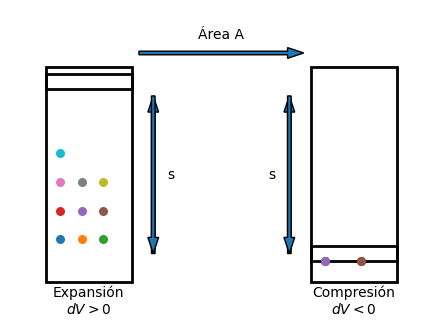

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

fig, ax = plt.subplots(figsize=(8, 4))

# Parámetros geométricos
cyl_w, cyl_h = 1.2, 3.0      # ancho y altura del cilindro
space = 2.5                  # separación entre cilindros

# --- Cilindro izquierdo (Expansión) ---
x0 = 0
ax.add_patch(Rectangle((x0, 0), cyl_w, cyl_h, fill=False, lw=2))            # paredes
pist_top, pist_bot = cyl_h - 0.3, 0.3                                       # posiciones
ax.add_patch(Rectangle((x0, pist_top), cyl_w, 0.2, fill=False, lw=2))       # pistón inicial
for i in range(10):                                                         # “moléculas”
    ax.scatter(x0+0.2+(i%3)*0.3, 0.6+(i//3)*0.4, s=30)

# Flecha doble para s
for dy in (1, -1):
    ax.add_patch(FancyArrow(x0+cyl_w+0.3, pist_bot+0.1 if dy==1 else pist_top-0.1,
                            0, dy*(pist_top-pist_bot-0.2),
                            width=0.05, head_width=0.15,
                            length_includes_head=True))
ax.text(x0+cyl_w+0.5, (pist_top+pist_bot)/2, 's', va='center')
ax.text(x0+cyl_w/2, -0.45, 'Expansión\n$dV>0$', ha='center')

# --- Cilindro derecho (Compresión) ---
x1 = x0 + cyl_w + space
ax.add_patch(Rectangle((x1, 0), cyl_w, cyl_h, fill=False, lw=2))
ax.add_patch(Rectangle((x1, pist_bot), cyl_w, 0.2, fill=False, lw=2))
for i in range(6):
    ax.scatter(x1+0.2+(i%2)*0.5, pist_bot-(i//6)*0.1, s=30)

# Flecha doble para s
for dy in (1, -1):
    ax.add_patch(FancyArrow(x1-0.3, pist_bot+0.1 if dy==1 else pist_top-0.1,
                            0, dy*(pist_top-pist_bot-0.2),
                            width=0.05, head_width=0.15,
                            length_includes_head=True))
ax.text(x1-0.5, (pist_top+pist_bot)/2, 's', va='center', ha='right')
ax.text(x1+cyl_w/2, -0.45, 'Compresión\n$dV<0$', ha='center')

# --- Flecha horizontal para el área A ---
ax.add_patch(FancyArrow(x0+cyl_w+0.1, cyl_h+0.2,
                        x1-(x0+cyl_w)-0.2, 0,
                        width=0.05, head_width=0.15,
                        length_includes_head=True))
ax.text((x0+cyl_w+x1)/2, cyl_h+0.4, 'Área A', ha='center')

# Ajustes finales
ax.set_xlim(-0.5, x1+cyl_w+0.5)
ax.set_ylim(-0.5, cyl_h+0.8)
ax.set_aspect('equal')
ax.axis('off')
plt.show()


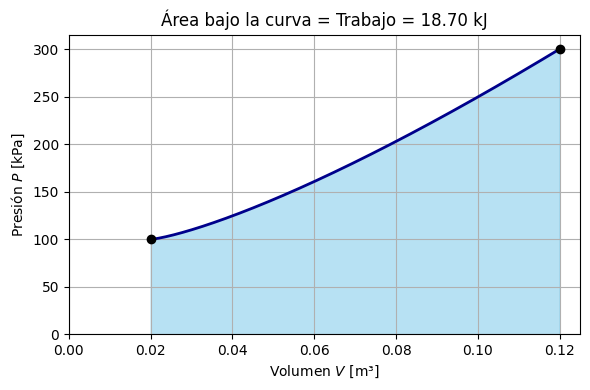

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Datos del proceso ---
P1, V1 = 100e3, 0.02      # estado 1  (Pa, m³)
P2, V2 = 300e3, 0.12      # estado 2  (Pa, m³)
alpha   = 1.3             # curvatura (1 = recta, >1 convexa)

# Trayectoria P(V)
t = np.linspace(0, 1, 300)
V = V1 + (V2 - V1) * t
P = P1 + (P2 - P1) * t**alpha

# Integración numérica
W = np.trapezoid(P, V)        # J

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(V, P/1e3, color='darkblue', lw=2)      # P en kPa
ax.scatter([V1, V2], [P1/1e3, P2/1e3], color='black', zorder=5)
ax.fill_between(V, 0, P/1e3, color='skyblue', alpha=0.6)

ax.set_xlabel('Volumen $V$ [m³]')
ax.set_ylabel('Presión $P$ [kPa]')
ax.set_title(f'Área bajo la curva = Trabajo = {W/1000:.2f} kJ')
ax.grid(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

---
## 1. Marco teórico
### 1.1 Definición de proceso politrópico
Un **proceso politrópico** para una sustancia simple compresible se describe por la relación:
$
P v^{n} = C
$
donde  
- $ P $ es la presión absoluta,  
- $ v $ es el volumen específico,  
- $ n $ es el **exponente politrópico**,  
- $ C $ es una constante que se mantiene invariante a lo largo del proceso.

La ecuación abarca numerosos procesos de interés industrial como casos particulares:

| Proceso | Condición | Exponente $ n $ |
|---------|-----------|---------------------|
| Isobárico | $ P = \text{cte} $ | $ n = 0 $ |
| Isotérmico (gas ideal) | $ T = \text{cte} $ | $ n = 1 $ |
| Isocórico | $ v = \text{cte} $ | $ n \to \infty $ |
| Adiabático reversible | $ Q=0 $ | $ n = k = c_{p}/c_{v} $ |

> **Nota**: El exponente $ n $ puede tomar cualquier valor real, incluso fuera de los casos mostrados; su magnitud refleja los intercambios de calor y trabajo durante el proceso.


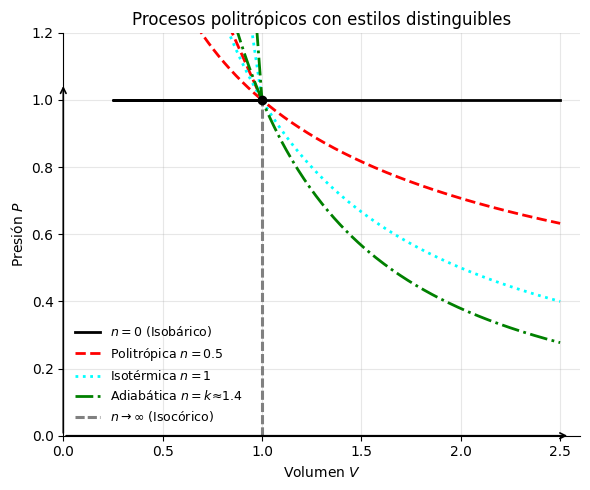

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Punto de intersección común
P0, V0 = 1.0, 1.0

# Rango de volúmenes
V_left  = np.linspace(0.25, V0, 150, endpoint=False)[::-1]
V_right = np.linspace(V0,   2.5, 150)
V_full  = np.concatenate([V_left, V_right])

def P_poly(V, n, P_ref=P0, V_ref=V0):
    return P_ref * (V_ref**n) / (V**n)

# Curvas con estilo (color de respaldo + tipo de línea)
curves = [
    {'label': r'$n=0$ (Isobárico)',        'n': 0,   'color': 'black',   'ls': '-'},      # línea sólida
    {'label': r'Politrópica $n=0.5$',      'n': 0.5, 'color': 'red', 'ls': '--'},     # guiones
    {'label': r'Isotérmica $n=1$',         'n': 1,   'color': 'cyan',   'ls': ':'},      # punteada
    {'label': r'Adiabática $n=k\!\approx\!1.4$', 'n': 1.4, 'color': 'green', 'ls': '-.'},  # punto-guion
]

fig, ax = plt.subplots(figsize=(6, 5))

for c in curves:
    P_vals = P_poly(V_full, c['n'])
    ax.plot(V_full, P_vals, lw=2,
            color=c['color'], linestyle=c['ls'], label=c['label'])

# Línea vertical (n → ∞, isocórico)
ax.plot([V0, V0], [0, P_poly(V_left[0], 0)],
        color='gray', lw=2.2, linestyle=(0, (3, 1)),  # patrón 3-1 para diferenciar
        label=r'$n\to\infty$ (Isocórico)')

# Punto de referencia
ax.scatter([V0], [P0], color='black', zorder=5)

# Ejes y anotaciones
ax.set_xlabel('Volumen $V$')
ax.set_ylabel('Presión $P$')
ax.set_xlim(0, 2.6)
ax.set_ylim(0, 1.2 * P_poly(V_left[0], 0))
ax.grid(alpha=0.3)
ax.legend(frameon=False, fontsize=9)

# Flechas de eje estilo cartesiano
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines[['right', 'top']].set_color('none')
ax.annotate('', xy=(2.55, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=1.2))
ax.annotate('', xy=(0, 1.05 * P_poly(V_left[0], 0)), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=1.2))

plt.title('Procesos politrópicos con estilos distinguibles')
plt.tight_layout()
plt.show()



### 1.2 Trabajo en un proceso politrópico

Partiendo de la definición de trabajo por frontera móvil para un sistema cerrado cuasiequilibrado:
$
W = \int_{1}^{2} P\,dV
$
y sustituyendo la relación politrópica $P=C\,V^{-n}$:
$
W = \int_{V_1}^{V_2} C V^{-n}\,dV =
\begin{cases}
\displaystyle \frac{C}{1-n}\left(V_2^{\,1-n}-V_1^{\,1-n}\right) & n \neq 1 \\
\displaystyle C\ln\left(\frac{V_2}{V_1}\right) & n = 1
\end{cases}
$

Expresándolo en términos de las condiciones de frontera:
$
W = \frac{P_2 V_2 - P_1 V_1}{1-n}, \qquad n \neq 1
$

Para un **gas ideal** ($P V = R T$):
$
w (\text{por unidad de masa}) = \frac{R (T_2-T_1)}{1-n}
$

Para el caso **adiabático reversible** ($ n = k $):
$
w = \frac{R T_1}{k-1}\left[1-\left(\frac{P_2}{P_1}\right)^{\tfrac{k-1}{k}}\right]
$


### Derivación del trabajo para un proceso politrópico  

#### 1. Punto de partida  

Para un sistema cerrado, el trabajo asociado al desplazamiento cuasi-estático es  

$$
W_{1\rightarrow 2}= \int_{1}^{2} P \, dV
$$

#### 2. Relación politrópica  

En un **proceso politrópico** se cumple  

$$
P\,v^{\,n}=C \qquad\Longrightarrow\qquad P = C\,v^{-n}
$$

donde  
* $v$ = volumen **específico** (o usar $V$ para volumen total),  
* $n$ = exponente politrópico,  
* $C$ = constante idéntica en todo el proceso.

#### 3. Sustitución en la integral  

$$
\begin{aligned}
W_{1\rightarrow 2}
&= \int_{1}^{2} C\,v^{-n}\,dv \\[4pt]
&= C\int_{1}^{2} v^{-n}\,dv \\[4pt]
&= C\;\Bigl[\tfrac{v^{\,1-n}}{1-n}\Bigr]_{1}^{2} \\[8pt]
&= \boxed{ \displaystyle
\frac{C}{\,1-n}\,\bigl(v_{2}^{\,1-n} - v_{1}^{\,1-n}\bigr) } \qquad(n\neq 1)
\end{aligned}
$$

> Para $n=1$ (proceso isotérmico) la integral conduce a  
> $W = C\,\ln\dfrac{v_2}{v_1}$.

#### 4. Expresiones útiles de la constante $C$

Dado que $C = P_1 v_1^{\,n}=P_2 v_2^{\,n}$, se obtienen formas equivalentes:

$$
\boxed{
W_{1\rightarrow 2}
=\frac{P_2 v_2 - P_1 v_1}{\,1-n}}
$$

o bien

$$
\boxed{
W_{1\rightarrow 2}
=\frac{P_2 \, v_2^{\,n+1-n} - P_1 \, v_1^{\,n+1-n}}{\,1-n}}
$$

#### 5. Caso **gas ideal**  

Si el fluido se comporta como gas ideal $P v = R T$ (por unidad de masa,  
o $P V = n R T$ para moles), se reemplaza $P = \dfrac{R T}{v}$:

$$
W_{1\rightarrow 2}
=\frac{R\,T}{\,1-n}\,(T_2 - T_1)
$$

o, tomando $T_1$ como factor común,

$$
\boxed{
W_{1\rightarrow 2}
= \frac{R\,T_1}{n-1}\Bigl(1 - \frac{T_2}{T_1}\Bigr)}
\qquad(n\neq 1)
$$

#### 6. Relación entre presiones y temperaturas  

De la relación politrópica

$$
\frac{P_2}{P_1} = \Bigl(\frac{v_1}{v_2}\Bigr)^{n},
$$

y usando $P v = R T$:

$$
\Bigl(\frac{P_2}{P_1}\Bigr)^{\,1-n}
  = \Bigl(\frac{T_1}{T_2}\Bigr)^{n},
\qquad
\frac{T_2}{T_1} = \Bigl(\frac{P_2}{P_1}\Bigr)^{\frac{n-1}{n}}.
$$

#### 7. Trabajo en función de presiones (gas ideal)  

Sustituyendo la relación anterior en la expresión del trabajo:

$$
\boxed{
W_{1\rightarrow 2} =
\frac{R\,T_1}{\,n-1}\,
\Bigl[\,1 - \Bigl(\frac{P_2}{P_1}\Bigr)^{\frac{n-1}{n}}\Bigr]}
$$

---

#### Resumen de formas del trabajo politrópico  

| Forma | Expresión |
|-------|-----------|
| General (con $C$) | $ W = \dfrac{C}{1-n}\bigl(v_2^{\,1-n} - v_1^{\,1-n}\bigr) $ |
| Con $P$ y $v$ | $ W = \dfrac{P_2 v_2 - P_1 v_1}{1-n} $ |
| Gas ideal (con $T$) | $ W = \dfrac{R(T_2 - T_1)}{1-n} = \dfrac{R\,T_1}{n-1}\!\left(1 - \dfrac{T_2}{T_1}\right) $ |
| Gas ideal (con $P$) | $ W = \dfrac{R\,T_1}{n-1}\!\left[1 - \bigl(P_2/P_1\bigr)^{(n-1)/n}\right] $ |

> *Casos límite*  
> - $n=0$ → **isobárico** ($W = P\,[V_2-V_1]$)  
> - $n=1$ → **isotérmico** ($W = R\,T\ln[V_2/V_1]$)  
> - $n \to \infty$ → **isocórico** ($W=0$)  
> - $n=k$ (exponente adiabático) → **adiabático reversible**.


##1.3 Trabajo en un Proceso Isobárico

Un **proceso isobárico** se caracteriza por mantener la presión $P$ constante mientras el volumen cambia de $V_1$ a $V_2$.

- **Expansión**: $V_2 > V_1$  → $W>0$ (el sistema realiza trabajo sobre el entorno).  
- **Compresión**: $V_2 < V_1$ → $W<0$ (el entorno realiza trabajo sobre el sistema).

### Cálculo del trabajo

$
W \;=\; \int_{1}^{2} P\,dV \;=\; P \int_{V_1}^{V_2} dV \;=\; P\,(V_2 - V_1)
$

Si el fluido es un **gas ideal**, usando $PV = mRT$:

$
W \;=\; P(V_2 - V_1) \;=\; mR(T_2 - T_1)
$

donde  
- $m$ es la masa del gas,  
- $R$ la constante de gas específico,  
- $T_1, T_2$ las temperaturas inicial y final.

> **Signo del trabajo**  
> - Convención de Ingeniería: $W>0$ cuando el sistema entrega energía al entorno (expansión).  
> - Convención de Física: a veces se usa el signo opuesto; especifica la convención empleada.

### Interpretación geométrica

- En el diagrama $P-V$, la curva es una línea **horizontal**.  
- El **área bajo la curva** entre $V_1$ y $V_2$ representa el trabajo $W$.

---

### Ejemplo numérico

Supongamos:  
- $P = 200 \text{ kPa}$ (constante)  
- $V_1 = 0.03 \text{ m}^3$ → $T_1 = 300 \text{ K}$
- $V_2 = 0.08 \text{ m}^3$ → $T_2 = 800 \text{ K}$  

Para aire $(R = 0.287 \text{ kJ/(kg·K)})$ y $m = 1 \text{ kg}$:

$
W = mR(T_2 - T_1) = 1 \times 0.287\,\text{kJ/(kg·K)} \times (800-300)\,\text{K} = 143.5 \text{ kJ}
$

En la celda Python siguiente realizamos el cálculo y graficamos el área.


In [ ]:
# %% [python]  Ejemplo interactivo: proceso isobárico
import numpy as np
import matplotlib.pyplot as plt

# --- Datos del ejemplo (puedes cambiarlos) -------------------------------
P = 250e3          # Pa  (presión constante)
V1, V2 = 0.04, 0.10  # m³
n  = 1.5           # moles (para cálculo con gas ideal)
R  = 8.314         # J/(mol·K)
T1 = 300           # K    (estado 1)
# -------------------------------------------------------------------------

# Volumen para la gráfica
V = np.linspace(V1, V2, 50)
P_line = P * np.ones_like(V)

# Trabajo por el área (integral analítica o numérica, deben coincidir)
W_analitico = P * (V2 - V1)               # J
W_num       = np.trapz(P_line, V)         # J

# Temperatura 2 si se usa gas ideal a P cte: PV = nRT
T2 = T1 * V2 / V1
W_idealgas = n * R * (T2 - T1)            # J

# --- Gráfica --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(V, P_line/1e3, 'b', lw=2, label='Proceso isobárico')  # P en kPa
ax.fill_between(V, 0, P_line/1e3, color='skyblue', alpha=0.5)
ax.scatter([V1, V2], [P/1e3, P/1e3], color='k', zorder=5)

ax.set_xlabel('Volumen $V$ [m³]')
ax.set_ylabel('Presión $P$ [kPa]')
ax.set_title('Área = Trabajo\n'
             f'W = {W_analitico/1000:.2f} kJ')
ax.grid(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

# --- Salida numérica en consola ------------------------------------------
print(f'Trabajo analítico  : {W_analitico/1000:.3f} kJ')
print(f'Trabajo numérico   : {W_num/1000:.3f} kJ')
print(f'Trabajo (gas ideal): {W_idealgas/1000:.3f} kJ')
print(f'Temperatura final  : {T2:.1f} K')


## 1.4 Trabajo en un Proceso Isotérmico  

- El proceso **isotérmico** se desarrolla a temperatura constante; puede ser  
  **compresión** $(1 \rightarrow 2)$ o **expansión** $(2 \rightarrow 1)$.

- Para integrar el trabajo, se debe expresar la presión como función del volumen,  
  ya que la integral se evalúa respecto a $V$.  
  Para un **gas ideal** se tiene  
  $
  P = \frac{RT}{v},
  $  
  donde $v$ es el volumen *específico* (por unidad de masa).  
  De forma equivalente usando volumen total $V$ y número de moles $n$:  
  $
  P = \frac{nRT}{V}.
  $

- Sustituyendo en la integral:  
$
\begin{aligned}
W_{1\rightarrow 2} &= \int_{1}^{2} P\,dV
                   \;=\; \int_{1}^{2} \frac{nRT}{V}\,dV
                   \;=\; nRT \int_{1}^{2} \frac{dV}{V}
                   \;=\; nRT\,\bigl[\ln V\bigr]_{1}^{2}\$4pt]
                   &= \boxed{\,nRT \,\ln\!\Bigl(\dfrac{V_2}{V_1}\Bigr)\,}.
\end{aligned}
$

- Usando de nuevo la ecuación de gas ideal $\tfrac{P_1V_1}{T} = \tfrac{P_2V_2}{T}$  
  (con $T$ constante), la razón de volúmenes puede escribirse como razón de presiones:  
  $
  \frac{V_2}{V_1} = \frac{P_1}{P_2}.
  $  

- Por tanto, otra forma útil es  
  $
  \boxed{\,W_{1\rightarrow 2} = nRT \,\ln\!\Bigl(\dfrac{P_1}{P_2}\Bigr)\,}.
  $

- **Signo del trabajo**  
  - **Expansión isotérmica** $(V_2 > V_1)$: $W > 0$.  
  - **Compresión isotérmica** $(V_2 < V_1)$: $W < 0$.

> **Interpretación gráfica**  
> El área bajo la curva hiperbólica $P = nRT/V$ en el diagrama $P\!-\!V$  
> representa exactamente $W$.


In [ ]:
# %% [python]  Ejemplo y verificación del trabajo isotérmico
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del proceso isotérmico -----------------------
n  = 1.2        # moles
T  = 350        # K  (temperatura constante)
R  = 8.314      # J/(mol·K)

P1 = 400e3      # Pa
P2 = 120e3      # Pa

# Volúmenes a partir de la ecuación de estado (nRT = P·V)
V1 = n * R * T / P1
V2 = n * R * T / P2

# --- Curva isotérmica para la gráfica ------------------------
V_curve = np.linspace(V1, V2, 300)
P_curve = n * R * T / V_curve

# --- Cálculo analítico del trabajo ---------------------------
W_analitico = n * R * T * np.log(V2 / V1)      # J

# --- Cálculo numérico (verificación) -------------------------
W_num = np.trapezoid(P_curve, V_curve)             # J

# --- Gráfica P-V con área -----------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(V_curve, P_curve/1e3, color='tab:brown', lw=2, label='Isotérmico')
ax.fill_between(V_curve, 0, P_curve/1e3, color='bisque', alpha=0.6)

# puntos inicial y final
ax.scatter([V1, V2], [P1/1e3, P2/1e3], color='black', zorder=5)
ax.text(V1, P1/1e3, ' 1', va='bottom', ha='left')
ax.text(V2, P2/1e3, ' 2', va='top',    ha='right')

ax.set_xlabel('Volumen $V$ [m³]')
ax.set_ylabel('Presión $P$ [kPa]')
ax.set_title('Trabajo isotérmico\n'
             f'W = {W_analitico/1000:.2f} kJ')
ax.grid(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

# --- Resultados numéricos en consola -------------------------
print(f'Trabajo analítico  : {W_analitico/1000:.3f} kJ')
print(f'Trabajo numérico   : {W_num/1000:.3f} kJ')
print(f'Volumen inicial V1 : {V1:.4f} m³')
print(f'Volumen final   V2 : {V2:.4f} m³')


##1.5 Trabajo en un Proceso Isocórico  

- El proceso **isocórico** (también llamado isométrico o a **volumen constante**) se describe por  
  $V = \text{cte}$. Durante él pueden **aumentar** la presión y la temperatura  
  $(1 \rightarrow 2)$ o **disminuir** $(2 \rightarrow 1)$.

- Como el trabajo mecánico se define por  
  $
  W \;=\; \int_{1}^{2} P \, dV,
  $  
  y en un isocórico $dV = 0$, entonces  

  $
  \boxed{\,W_{1\rightarrow 2} = 0\;}
  $

  para un **sistema cerrado**.

- Consecuencias importantes  
  - Toda la energía transferida al sistema (o desde él) **no** puede ser  
    trabajo $P\,dV$; se manifiesta como transferencia de **calor $Q$**.  
  - Para un **gas ideal**, la primera ley $ \Delta U = Q - W $ se reduce a  
    $\Delta U = Q$, y  
    $
    \Delta U = n\,c_v\,(T_2 - T_1).
    $  

> **Interpretación gráfica**  
> En el diagrama $P\!-\!V$, la curva es una **línea vertical**.  
> El área a la izquierda (o derecha) de esta línea no cambia:  
> $W = 0$.


In [ ]:
# %% [python]  Ejemplo numérico de proceso isocórico
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros ----------------------------------------------------------
n  = 1.0      # moles
V  = 0.05     # m³  (volumen constante)
T1 = 300      # K   (estado 1)
T2 = 600      # K   (estado 2)  --> calefacción isocórica
R  = 8.314    # J/(mol·K)

P1 = n * R * T1 / V     # Pa
P2 = n * R * T2 / V     # Pa

# --- Curva isocórica (vertical) -----------------------------------------
P_curve = np.linspace(P1, P2, 200)
V_curve = V * np.ones_like(P_curve)

# --- Cálculo del trabajo -------------------------------------------------
W_analitico = 0.0                   # J  (por definición)
W_num       = np.trapz(P_curve, V_curve)  # ≈ 0 numéricamente

# --- Gráfica -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(V_curve, P_curve/1e3, 'purple', lw=2, label='Isocórico')
ax.fill_between(V_curve, 0, P_curve/1e3, color='violet', alpha=0.15)  # solo decorativo
ax.scatter([V, V], [P1/1e3, P2/1e3], color='black', zorder=5)
ax.text(V, P1/1e3, ' 1', va='bottom', ha='left')
ax.text(V, P2/1e3, ' 2', va='top',    ha='left')

ax.set_xlabel('Volumen $V$ [m³]')
ax.set_ylabel('Presión $P$ [kPa]')
ax.set_title('Proceso isocórico (V = const.)\nTrabajo W = 0')
ax.grid(True)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

# --- Resultados en consola ----------------------------------------------
print(f'Trabajo analítico  : {W_analitico:.3f} kJ')
print(f'Trabajo numérico   : {W_num/1000:.6f} kJ (≈0)')
print(f'Presión inicial P1 : {P1/1e3:.1f} kPa')
print(f'Presión final   P2 : {P2/1e3:.1f} kPa')


## 2. Ejemplo práctico con Python

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def trabajo_polytropic(P1, V1, P2=None, V2=None, n=1.3):
    """Calcula el trabajo de un proceso politrópico para un sistema cerrado.
    Si se conocen P1, V1 y P2, n, se determina V2 mediante la relación politrópica.
    Parámetros
    ----------
    P1, V1 : float
        Condiciones iniciales (SI: Pa, m^3).
    P2, V2 : float, opcional
        Una de las dos condiciones finales. Si V2 es None se calcula a partir de P2 y viceversa.
    n : float
        Exponente politrópico. n=1 se maneja como caso isotérmico.
    """
    # Determinar V2 o P2
    if V2 is None and P2 is not None:
        V2 = (P1 * V1**n / P2)**(1/n)
    elif P2 is None and V2 is not None:
        P2 = P1 * (V1 / V2)**n
    elif V2 is None and P2 is None:
        raise ValueError('Debe proveer P2 o V2')

    if n == 1:
        W = P1 * V1 * np.log(V2 / V1)
    else:
        W = (P2 * V2 - P1 * V1) / (1 - n)
    return W, P2, V2

# --- Ejemplo numérico ---
R_air = 287.0       # J/(kg·K)
P1 = 101.3e3        # Pa
T1 = 300            # K
V1 = R_air*T1/P1    # m^3/kg, usando gas ideal

n = 1.3             # proceso de compresión politrópico
P2 = 5*P1           # Presión final (5 veces la inicial)

W, P2_calc, V2 = trabajo_polytropic(P1, V1, P2=P2, n=n)
print(f"Trabajo específico: {W/1000:.2f} kJ/kg")

# Graficar la curva P-V (log-log para claridad)
V = np.logspace(np.log10(V1), np.log10(V2), 100)
P = P1 * (V1**n) / (V**n)

plt.figure()
plt.loglog(V, P)
plt.scatter([V1, V2], [P1, P2], color='red')
plt.xlabel('Volumen específico [m³/kg]')
plt.ylabel('Presión [Pa]')
plt.title('Proceso politrópico n=1.3')
plt.grid(True, which="both", ls='--')
plt.show()

## 3. Actividades propuestas
1. **Compresión isotérmica de nitrógeno**  
   - Se parte de $P_1 = 200\;\text{kPa}$, $T_1 = 300\;\text{K}$ y se comprime isotérmicamente hasta $P_2 = 600\;\text{kPa}$.  
   - Calcule el trabajo específico y compare su signo respecto a un proceso de expansión.

2. **Expansión adiabática de aire en un cilindro**  
   - $P_1 = 1\;\text{MPa}$, $T_1 = 500\;\text{K}$. El gas se expande hasta que la presión cae a $200\;\text{kPa}$. Suponga $k = 1.4$.  
   - Determine $T_2$, $V_2$ y $w$.

3. **Efecto del exponente politrópico**  
   - Mantenga $P_1, V_1$ constantes y fije $P_2 = 5P_1$. Escriba un script que grafique $w(n)$ para $0.5 \leq n \leq 2$.  
   - Analice qué valores de $n$ conducen a mayor gasto de energía durante la compresión.

> Entregue sus respuestas y código en el espacio indicado en el repositorio de la asignatura.


---
## 4. Referencias
- Borgnakke, C. & Sonntag, R. (2013). *Fundamentals of Thermodynamics*. 8ª ed.  
- Çengel, Y. & Boles, M. (2015). *Termodinámica*. 8ª ed.  
- Anderson, G. (2005). *Thermodynamics of Natural Systems*.  
